In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Read the data
df = pd.read_csv(
    r"C:\Users\jason\PyCharmMiscProject\credit-risk-modeling\data\raw\accepted_2007_to_2018Q4.csv.gz",
    compression='gzip',
    low_memory=False,
    na_values=['n/a', 'N/A', '']  # Handle missing values consistently
)

print(f"Dataset shape: {df.shape}")
print(f"Default rate: {(df['loan_status'].isin(['Charged Off', 'Default']).sum() / len(df) * 100):.2f}%")

df.head

KeyboardInterrupt: 

In [32]:
df = df[df['loan_amnt'].notna()].copy()
print(f"After Cleaning: {df.shape}")

After Cleaning: (2260668, 151)


In [33]:
#Create Target Variable
df['default'] = df['loan_status'].isin(['Charged Off', 'Default']).astype(int)

#Check class balance
print("\nDefault Ditribution")
print(df['default'].value_counts(normalize = True))


Default Ditribution
default
0    0.881186
1    0.118814
Name: proportion, dtype: float64


In [34]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
Name: count, dtype: int64


In [35]:
#Summary stats for key features
key_features = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'revol_util']

print("\nKey Features")
print(df[key_features].describe())


Key Features
          loan_amnt      int_rate   installment    annual_inc           dti  \
count  2.260668e+06  2.260668e+06  2.260668e+06  2.260664e+06  2.258957e+06   
mean   1.504693e+04  1.309283e+01  4.458068e+02  7.799243e+04  1.882420e+01   
std    9.190245e+03  4.832138e+00  2.671735e+02  1.126962e+05  1.418333e+01   
min    5.000000e+02  5.310000e+00  4.930000e+00  0.000000e+00 -1.000000e+00   
25%    8.000000e+03  9.490000e+00  2.516500e+02  4.600000e+04  1.189000e+01   
50%    1.290000e+04  1.262000e+01  3.779900e+02  6.500000e+04  1.784000e+01   
75%    2.000000e+04  1.599000e+01  5.933200e+02  9.300000e+04  2.449000e+01   
max    4.000000e+04  3.099000e+01  1.719830e+03  1.100000e+08  9.990000e+02   

       fico_range_low  fico_range_high    revol_util  
count    2.260668e+06     2.260668e+06  2.258866e+06  
mean     6.985882e+02     7.025884e+02  5.033770e+01  
std      3.301038e+01     3.301124e+01  2.471307e+01  
min      6.100000e+02     6.140000e+02  0.000000e+00  

In [36]:
#Data Cleaning
completes_statuses = ['Fully Paid', 'Charged Off', 'Default',
                      'Does not meet the credit policy. Status:Fully Paid',
                      'Does not meet the credit policy. Status:Charged Off']

df_clean = df[df['loan_status'].isin(completes_statuses)].copy()

print(f"Original size: {len(df):,}")
print(f"After filtering to completed loans: {len(df_clean):,}")

#Create target variables
df_clean['default'] = df_clean['loan_status'].isin([
    'Charged Off',
    'Default',
    'Does not meet the credit policy. Status:Charged Off'
]).astype(int)

print(f"\nDefault rate in completed loans: {df_clean['default'].mean()*100:.2f}%")

#Clean DTI (Remove impossible values
df_clean = df_clean[(df_clean['dti'] >= 0) & (df_clean['dti'] <= 100)].copy()

print(f"After cleaning DTi: {len(df_clean):,}")

#Clean other numeric features
df_clean = df_clean[df_clean['annual_inc'] > 0].copy() #remove $0 income

print(f"Final Clean dataset: {len(df_clean):}")
print(f"Final default rate: {df_clean['default'].mean()*100:.2f}%")


Original size: 2,260,668
After filtering to completed loans: 1,348,099

Default rate in completed loans: 19.98%
After cleaning DTi: 1,347,190
Final Clean dataset: 1347186
Final default rate: 19.98%


In [40]:
#Default rate by grade
print("\nDefault rate by grade:")

grade_default = df_clean.groupby('grade')['default'].agg(['mean', 'count'])
grade_default.columns = ['Default Rate', 'Count']
print(grade_default)


Default rate by grade:
       Default Rate   Count
grade                      
A          0.060437  235104
B          0.133970  392886
C          0.224406  382030
D          0.303780  201475
E          0.384375   94106
F          0.451501   32279
G          0.496669    9306


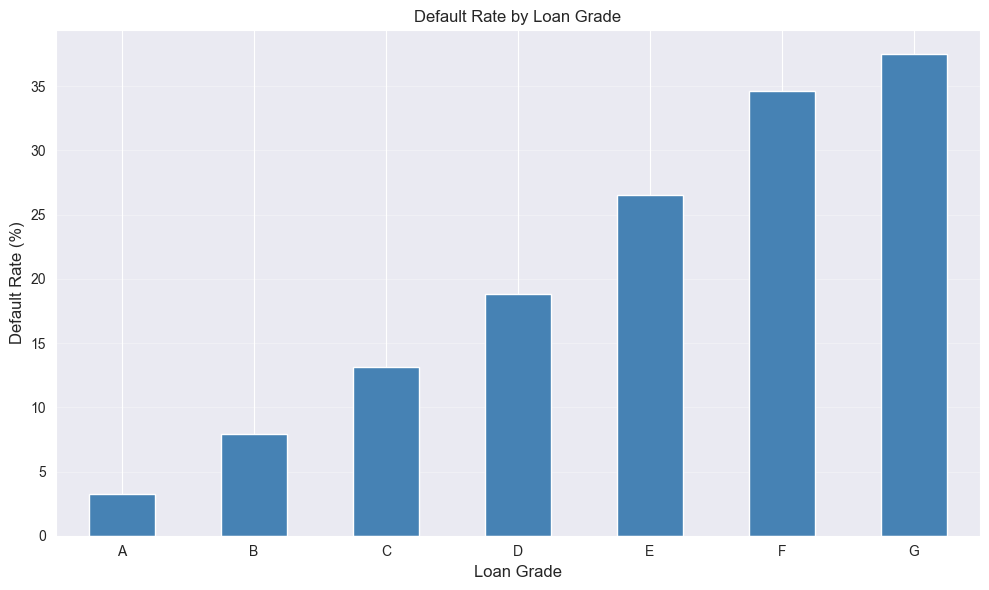

In [41]:
#Visualize Default Rate By Grade
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (10,6))
grade_default_rate = df.groupby('grade')['default'].mean() * 100
grade_default_rate.plot(kind='bar', color = 'steelblue')
plt.title('Default Rate by Loan Grade', fontsize = 12)
plt.xlabel('Loan Grade', fontsize = 12)
plt.ylabel('Default Rate (%)', fontsize = 12)
plt.xticks(rotation = 0)
plt.grid(axis='y', alpha = 0.3)
plt.tight_layout()
plt.show()


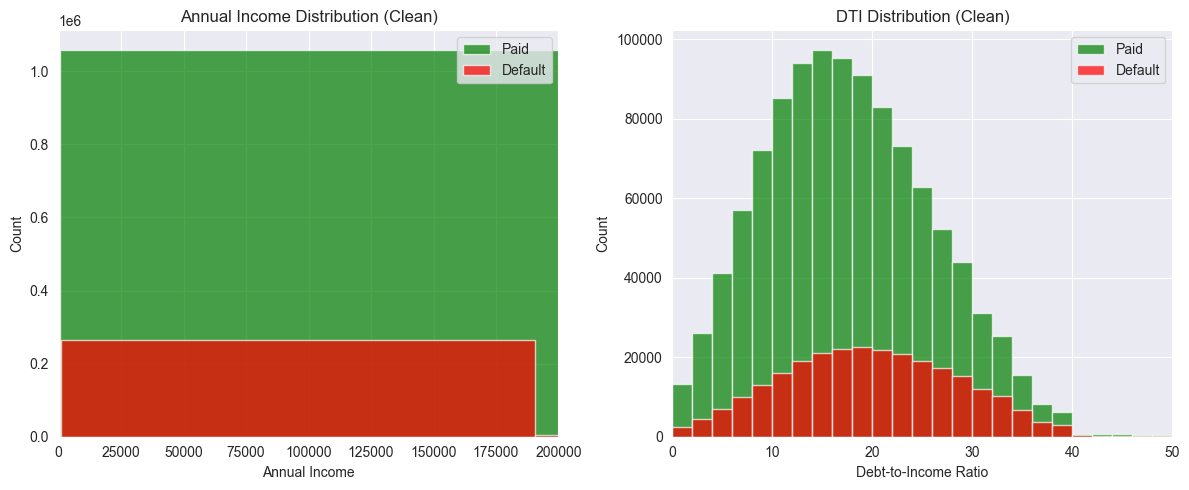

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df_clean[df_clean['default']==0]['annual_inc'].hist(bins=50, alpha=0.7, label='Paid', color='green')
df_clean[df_clean['default']==1]['annual_inc'].hist(bins=50, alpha=0.7, label='Default', color='red')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.title('Annual Income Distribution (Clean)')
plt.legend()
plt.xlim(0, 200000)

plt.subplot(1, 2, 2)
df_clean[df_clean['default']==0]['dti'].hist(bins=50, alpha=0.7, label='Paid', color='green')
df_clean[df_clean['default']==1]['dti'].hist(bins=50, alpha=0.7, label='Default', color='red')
plt.xlabel('Debt-to-Income Ratio')
plt.ylabel('Count')
plt.title('DTI Distribution (Clean)')
plt.legend()
plt.xlim(0, 50)  # Reasonable DTI range

plt.tight_layout()
plt.show()

What the above data shows:

1.35M completed loans, 20% default rate

Grade is highly predictive:
- Grade A: 6% default
- Grade G: 50% default
- 8x difference - The strongest feature

DTI Matters:
The histogram shows defaulted loans (in red) skew toward higher DTI ratios. People with more debt relative to income default more often.

Income matters less than thought:

The distributions are similar. Low income does not equal automatic default. It is more about debt burden (DTI).

Next: Feature Engineering code below.

In [45]:
# Feature Engineering
df_model = df_clean.copy()

# 1. Credit utilization (how much of available credit is being used)
df_model['credit_utilization'] = df_model['revol_util']

# 2. Loan amount as % of annual income (big loan relative to income = risky)
df_model['loan_to_income'] = (df_model['loan_amnt'] / df_model['annual_inc']) * 100

# 3. FICO score (average of low and high range)
df_model['fico_score'] = (df_model['fico_range_low'] + df_model['fico_range_high']) / 2

# 4. Monthly debt burden (installment as % of monthly income)
df_model['monthly_income'] = df_model['annual_inc'] / 12
df_model['payment_to_income'] = (df_model['installment'] / df_model['monthly_income']) * 100

# 5. Loan term (36 or 60 months - convert to numeric)
df_model['term_months'] = df_model['term'].str.extract(r'(\d+)').astype(int)

# 6. Employment length (convert to years)
# Handle "< 1 year" and "10+ years"
df_model['emp_length_years'] = df_model['emp_length'].str.extract(r'(\d+)').fillna(0).astype(int)
df_model.loc[df_model['emp_length'] == '< 1 year', 'emp_length_years'] = 0
df_model.loc[df_model['emp_length'] == '10+ years', 'emp_length_years'] = 10

# 7. Grade as numeric (A=1, B=2, ... G=7)
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df_model['grade_numeric'] = df_model['grade'].map(grade_map)

# 8. Home ownership (own home = less risky)
df_model['owns_home'] = (df_model['home_ownership'] == 'OWN').astype(int)
df_model['mortgage'] = (df_model['home_ownership'] == 'MORTGAGE').astype(int)

# 9. Loan purpose - create dummies for important purposes
df_model['purpose_debt_consolidation'] = (df_model['purpose'] == 'debt_consolidation').astype(int)
df_model['purpose_credit_card'] = (df_model['purpose'] == 'credit_card').astype(int)

print("Feature engineering complete!")
print(f"Total features created: {len(df_model.columns)}")

Feature engineering complete!
Total features created: 164


In [46]:
#CHECK FOR MISSING VALUES
features_to_use = [
    'loan_amnt', 'int_rate', 'installment', 'grade_numeric',
    'annual_inc', 'dti', 'fico_score', 'credit_utilization',
    'loan_to_income', 'payment_to_income', 'term_months',
    'emp_length_years', 'owns_home', 'mortgage',
    'purpose_debt_consolidation', 'purpose_credit_card', 'default'
]

print("\nMissing Values:")
print(df_model[features_to_use].isnull().sum())

#Drop rows with missing values in key features
df_model = df_model[features_to_use].dropna()

print(f"\nFinal modeling dataset: {len(df_model):,} rows")
print(f"Defaults rate: {df_model['default'].mean()*100:.2f}%")


Missing Values:
loan_amnt                       0
int_rate                        0
installment                     0
grade_numeric                   0
annual_inc                      0
dti                             0
fico_score                      0
credit_utilization            892
loan_to_income                  0
payment_to_income               0
term_months                     0
emp_length_years                0
owns_home                       0
mortgage                        0
purpose_debt_consolidation      0
purpose_credit_card             0
default                         0
dtype: int64

Final modeling dataset: 1,346,294 rows
Defaults rate: 19.98%



Feature Correlations with Defaults:
default                       1.000000
grade_numeric                 0.261292
int_rate                      0.258614
term_months                   0.175859
loan_to_income                0.128977
payment_to_income             0.114422
dti                           0.106920
loan_amnt                     0.065274
credit_utilization            0.059958
installment                   0.051361
purpose_debt_consolidation    0.034456
owns_home                     0.005568
emp_length_years             -0.028410
purpose_credit_card          -0.040345
annual_inc                   -0.041668
mortgage                     -0.068026
fico_score                   -0.130736
Name: default, dtype: float64


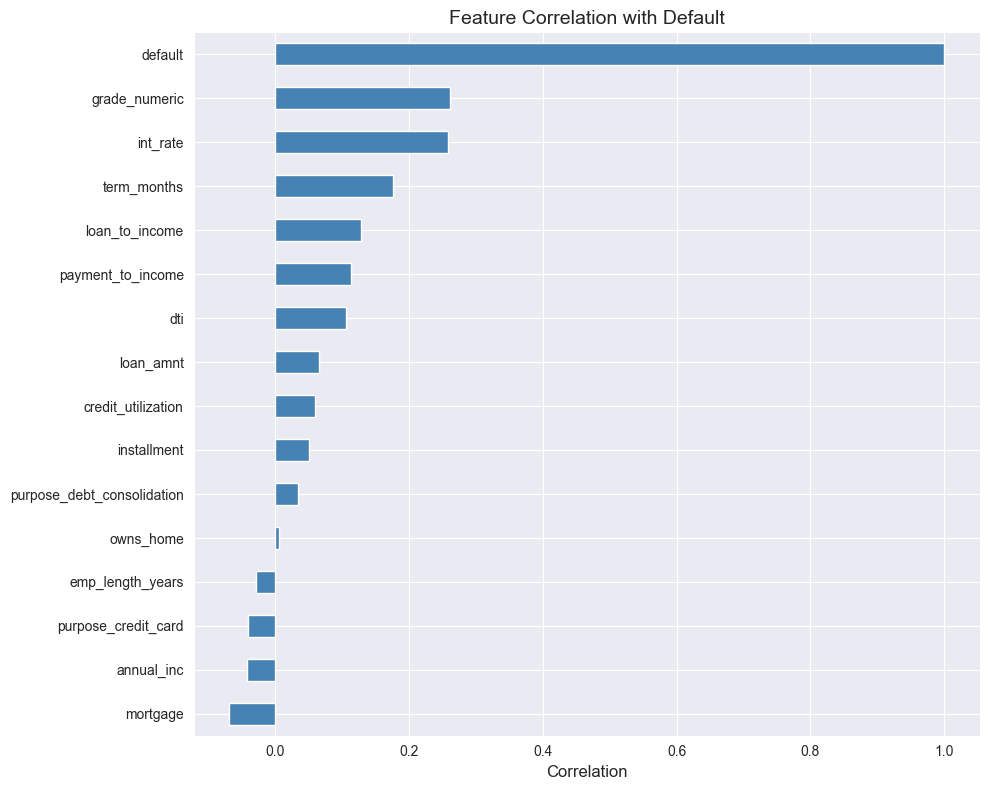

In [48]:
#FEATURE CORRELATIONS
#Correlation with default
feature_col = [col for col in features_to_use if col != 'default']
correlations = df_model[feature_col + ['default']].corr()['default'].sort_values(ascending=False)

print("\nFeature Correlations with Defaults:")
print(correlations)

#Visualize top correlations
plt.figure(figsize = (10, 8))
correlations[:-1].sort_values().plot(kind='barh', color = 'steelblue')
plt.title('Feature Correlation with Default', fontsize=14)
plt.xlabel('Correlation', fontsize=12)
plt.tight_layout()
plt.show()

Insights from Correlation

Top Predictors (Positive = Higher Default Risk):

1. Grade(0.26) - Worst loan grade = much higher default risk
2. Interest Rate (0.26) - Higher rate = higher risk (Lending Club charges more for risky borrowers)
3. Term Length (0.18) - 60-month loans default more than 36-month
4. Loan-to-income (0.13) - Borrowing too much related to income is more risky
5. DTI (0.11) - More existing debt = higher default risk

Protective Factors (Negative = Lower Default Risk):

1. FICO Score (-0.13) - Higher credit score = less likely to default
2. Mortgage (-0.07) - Having a mortgage = more stable, less risky
3. Annual Income (-0.04) - Higher income = slightly less risky

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb

#Prep the data
X = df_model[feature_col]
y = df_model['default']

#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train):,} loans")
print(f"Test set: {len(X_test):,} loans")
print(f"Default rate in train: {y_train.mean()*100:.2f}%")
print(f"Default rate in test: {y_test.mean()*100:.2f}%")

Training set: 1,077,035 loans
Test set: 269,259 loans
Default rate in train: 19.98%
Default rate in test: 19.98%


Model 1: Logistic Regression (This is the Baseline)

In [52]:
print("\n" + "="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)

#Train
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

#Predict
y_pred_lr = lr_model.predict(X_test)
y_pred_proba_lr = lr_model.predict_proba(X_test)[:, 1]

#Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_lr):.4f}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)
print("\nConfusion Matrix:")
print(cm)
print(f"True Negatives: {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives: {cm[1,1]:,}")


MODEL 1: LOGISTIC REGRESSION


C:\Users\jason\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89    215467
           1       0.51      0.07      0.13     53792

    accuracy                           0.80    269259
   macro avg       0.66      0.53      0.51    269259
weighted avg       0.75      0.80      0.74    269259


AUC-ROC: 0.5272

Confusion Matrix:
[[211760   3707]
 [ 49944   3848]]
True Negatives: 211,760
False Positives: 3,707
False Negatives: 49,944
True Positives: 3,848


Model 2: Random Forest

In [53]:
print("\n" + "="*50)
print("MODEL 2: RANDOM FOREST")
print("="*50)

#Train
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=1000,
    random_state=42,
    n_jobs=1
)
rf_model.fit(X_train, y_train)

#Predict
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

#Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_rf):.4f}")

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred_rf)
print("\nConfusion Matrix:")
print(cm)


MODEL 2: RANDOM FOREST

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215467
           1       0.59      0.04      0.08     53792

    accuracy                           0.80    269259
   macro avg       0.70      0.52      0.48    269259
weighted avg       0.76      0.80      0.73    269259


AUC-ROC: 0.7106

Confusion Matrix:
[[213880   1587]
 [ 51536   2256]]


Model 3: XGBoost

In [55]:
print("\n" + "="*50)
print("MODEL 3: XGBoost")
print("="*50)

xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=1
)
xgb_model.fit(X_train, y_train)

#Predict
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

#Evaluate
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)
print("\nConfusion Matrix:")
print(cm)


MODEL 3: XGBoost

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.99      0.89    215467
           1       0.57      0.07      0.12     53792

    accuracy                           0.80    269259
   macro avg       0.69      0.53      0.51    269259
weighted avg       0.76      0.80      0.74    269259


AUC-ROC: 0.7151

Confusion Matrix:
[[212641   2826]
 [ 50114   3678]]


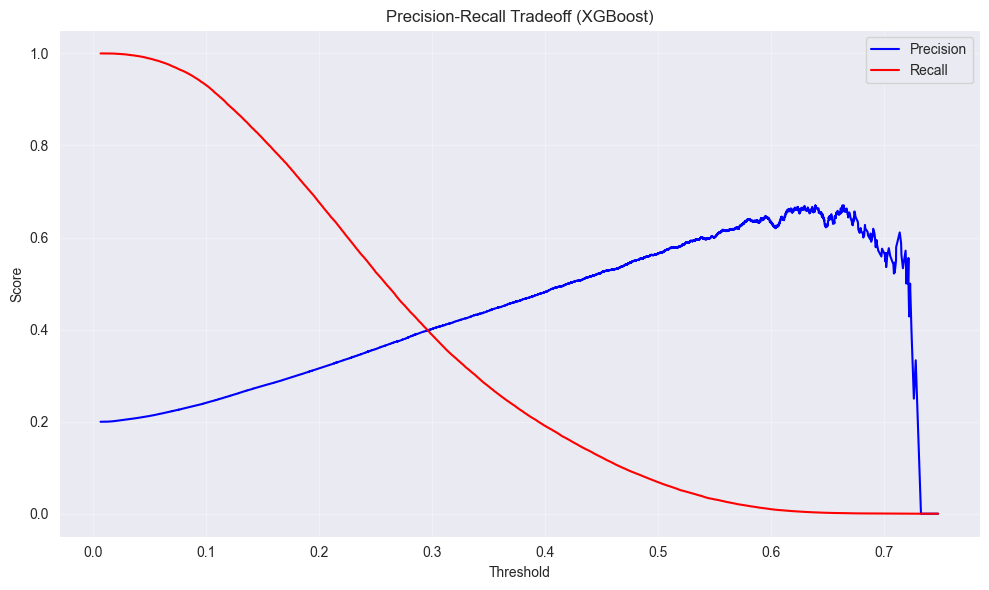


Optimal Threshold for 50% Recall: 0.259
At this threshold:
  Recall: 50.00%
  Precision: 36.59%


In [60]:
from sklearn.metrics import precision_recall_curve

#Use XGBoost (The best model of the three)
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)

#Plot precision-recall tradeoff
plt.figure(figsize=(10, 6))
plt.plot(thresholds, precision[:-1], label='Precision', color = 'blue')
plt.plot(thresholds, recall[:-1], label = 'Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff (XGBoost)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#Find threshold that gives 50% recall
target_recall = 0.50
idx = np.argmin(np.abs(recall - target_recall))
optimal_threshold = thresholds[idx]

print(f"\nOptimal Threshold for 50% Recall: {optimal_threshold:.3f}")
print(f"At this threshold:")
print(f"  Recall: {recall[idx]:.2%}")
print(f"  Precision: {precision[idx]:.2%}")

In [64]:
#Apply new threshold
optimal_threshold = 0.25

y_pred_xgb_tuned = (y_pred_proba_xgb >= optimal_threshold).astype(int)

print("\n" + "="*50)
print(f"XGBOOST WITH THRESHOLD = {optimal_threshold}")
print("="*50)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb_tuned))

print(f"\nAUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb_tuned)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0,0]:,}")
print(f"False Positives: {cm[0,1]:,}")
print(f"False Negatives: {cm[1,0]:,}")
print(f"True Positives: {cm[1,1]:,}")

#Calculate business metrics
false_negatives = cm[1,0]
true_positives = cm[1,1]
print(f"n% of Defaults Caught: {true_positives / (true_positives + false_negatives) * 100:.1f}%")


XGBOOST WITH THRESHOLD = 0.25

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.76      0.81    215467
           1       0.36      0.53      0.43     53792

    accuracy                           0.72    269259
   macro avg       0.61      0.64      0.62    269259
weighted avg       0.76      0.72      0.73    269259


AUC-ROC: 0.7151

Confusion Matrix:
[[164661  50806]
 [ 25527  28265]]

True Negatives: 164,661
False Positives: 50,806
False Negatives: 25,527
True Positives: 28,265
n% of Defaults Caught: 52.5%
